Mounted at /content/drive
📦 Extracting dataset...
✅ Extraction done!
📁 Using dataset path: /content/chest_xray
📂 Train folders: ['PNEUMONIA', 'NORMAL']
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
⚖️ Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 769ms/step - accuracy: 0.6079 - auc: 0.6688 - loss: 0.6575 - recall: 0.5966 - val_accuracy: 0.6250 - val_auc: 0.7656 - val_loss: 0.6572 - val_recall: 0.3750
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 762ms/step - accuracy: 0.6770 - auc: 0.7418 - loss: 0.5880 - recall: 0.6369 - val_accuracy: 0.6250 - val_auc: 0.7969 - val_loss: 0.6284 - val_recall: 0.3750
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 759ms/step - accuracy: 0.6791 - auc: 0.7588 - loss: 0.5630 - recall: 0.6222 - val_accuracy: 0.6250 - val_auc: 0.8906 - val_loss: 0.6286 - val_recall: 0.3750
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 768ms/step - accuracy: 0.6641 - auc: 0.7538 - loss: 0.5674 - recall: 0.5964 - val_accuracy: 0.6250 - val_auc: 0.8750 - val_loss: 0.6314 - val_recall: 0.3750
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 744ms/step - accuracy: 0.6603 - auc: 0.7717 - loss: 0.5499 - recall: 0.5781 - val_accuracy: 0.6250 - val_auc: 0.8906 - val_loss: 0.6211 - val_recal

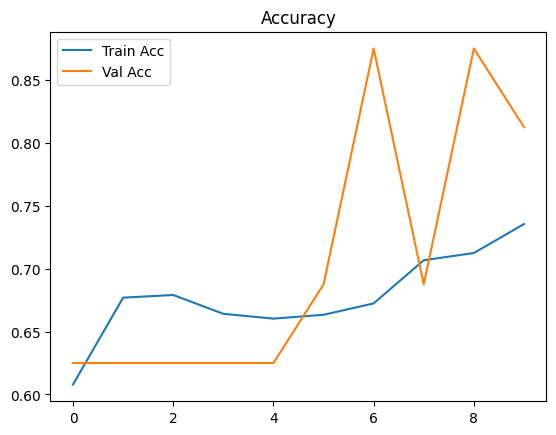

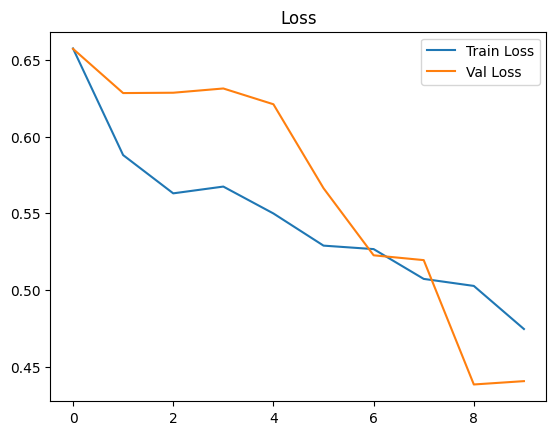

✅ Model saved!


In [1]:

from google.colab import drive
drive.mount('/content/drive')
import os
import zipfile
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/chest_xray.zip'    change if needed
EXTRACT_DIR = '/content/chest_xray'

if not os.path.exists(EXTRACT_DIR):
    print(" Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print("Extraction done!")
else:
    print("Already extracted")

# ================================
#  STEP 3: FIX PATH (FOR NESTED FOLDER)
# ================================
BASE_DIR = Path('/content/chest_xray')

# Handle nested case
if not (BASE_DIR / 'train').exists():
    BASE_DIR = BASE_DIR / 'chest_xray'

TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR   = BASE_DIR / 'val'
TEST_DIR  = BASE_DIR / 'test'

print(" Using dataset path:", BASE_DIR)
print(" Train folders:", os.listdir(TRAIN_DIR))

# ================================
#  STEP 4: IMPORT LIBRARIES
# ================================
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

IMG_SIZE = 224
BATCH_SIZE = 32

# ================================
# 📌 STEP 5: CLAHE FUNCTION
# ================================
def apply_clahe(img):
    img = (img * 255).astype(np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl,a,b))
    final = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return final / 255.0

# ================================
#  STEP 6: DATA GENERATORS
# ================================
train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=apply_clahe)
test_datagen = ImageDataGenerator(preprocessing_function=apply_clahe)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ================================
#  STEP 7: CLASS WEIGHTS
# ================================
classes = train_gen.classes
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(classes),
                                     y=classes)
class_weights = dict(enumerate(class_weights))

print("⚖️ Class Weights:", class_weights)

# ================================
# STEP 8: MODEL
# ================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), name='conv1'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', name='conv2'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', name='conv3'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()

# ================================
#  STEP 9: TRAIN
# ================================
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights
)

# ================================
# STEP 10: EVALUATION
# ================================
loss, acc, auc, recall = model.evaluate(test_gen)

print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Recall: {recall:.4f}")

# ================================
# STEP 11: CONFUSION MATRIX
# ================================
preds = model.predict(test_gen)
y_pred = (preds > 0.5).astype(int)

cm = confusion_matrix(test_gen.classes, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(test_gen.classes, y_pred, target_names=['NORMAL','PNEUMONIA']))

# ================================
#  STEP 12: SENSITIVITY & SPECIFICITY
# ================================
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

# ================================
#  STEP 13: PLOTS
# ================================
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# ================================
#  STEP 14: SAVE MODEL
# ================================
model.save("pneumonia_model_final.h5")
print("✅ Model saved!")